In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load dataset
df = pd.read_csv("../data/processed/featured_aqi_data.csv")

# Features
features = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "pm25",
    "pm10",
    "co",
    "no2",
    "o3",
    "hour",
    "day",
    "month",
    "day_of_week",
    "previous_aqi",
    "aqi_lag_3",
    "aqi_lag_6",
    "aqi_lag_12",
    "rolling_avg_3",
    "rolling_avg_6",
    "aqi_change"
]

X = df[features]
y = df["future_aqi"]

In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Load best model
model = joblib.load("../models/best_aqi_model.pkl")

# Predictions
predictions = model.predict(X_test)

##### PREDICTION VS ACTUAL

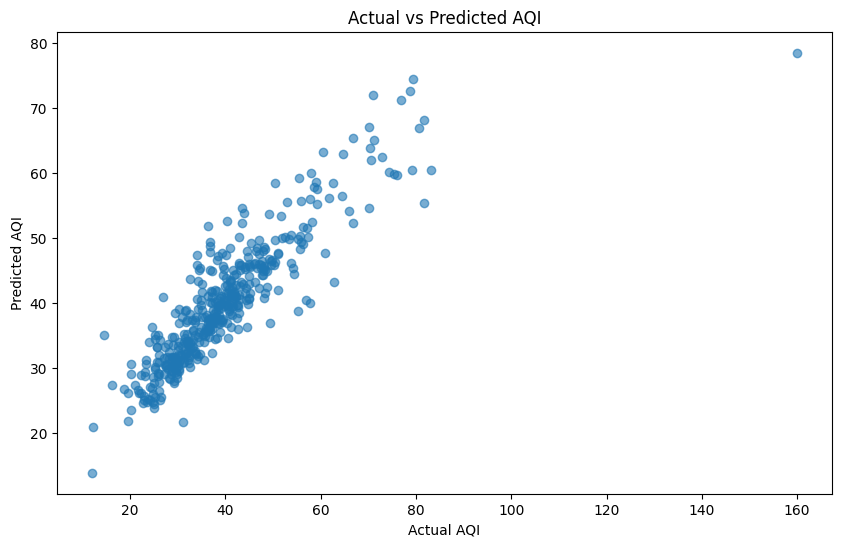

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.show()

##### RESIDUAL ANALYSIS

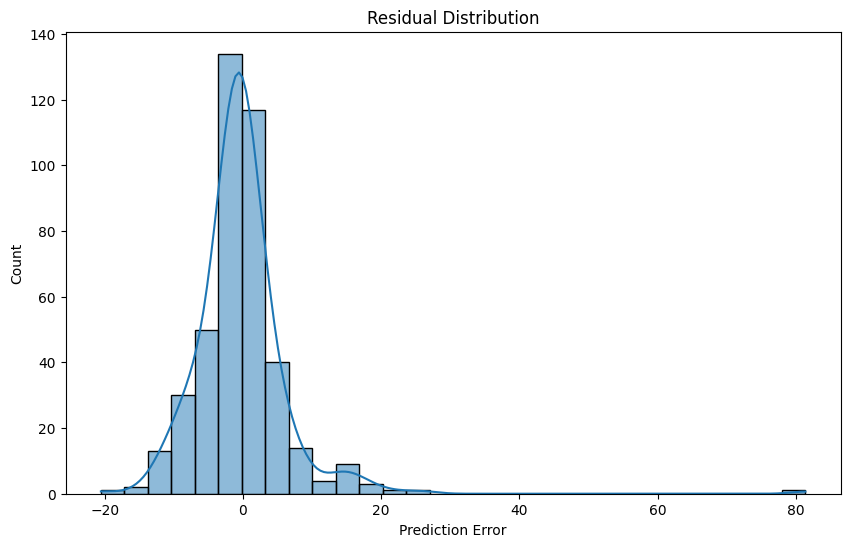

In [6]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

##### RANDOM FOREST FEATURE IMPORTANCE

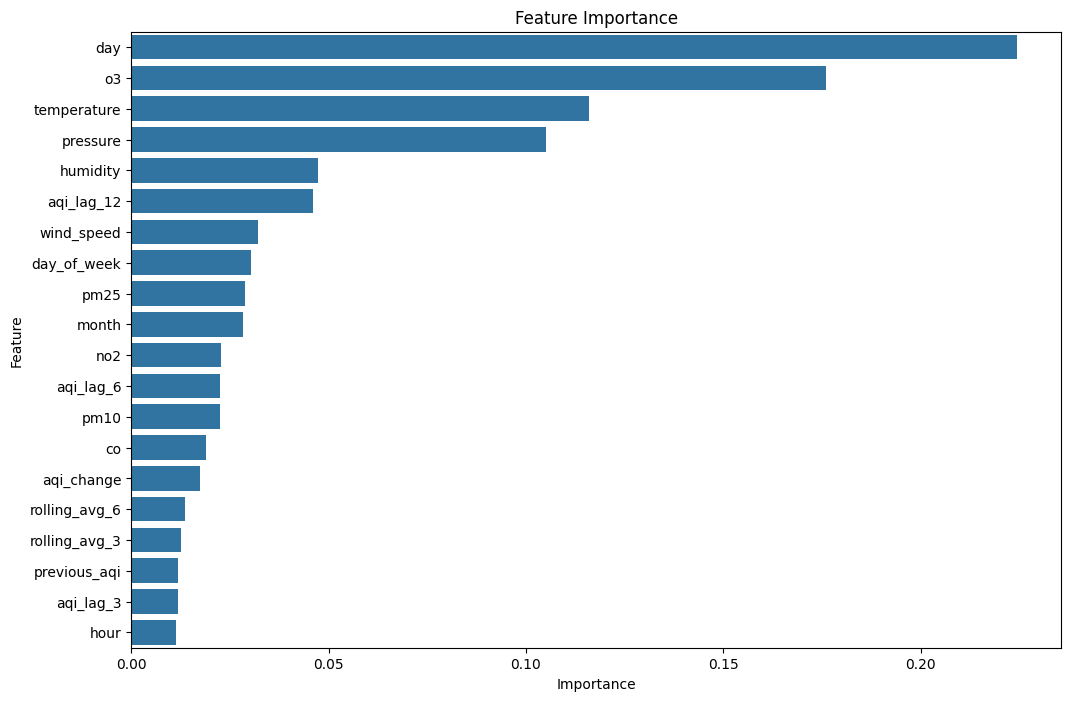

,Feature,Importance
10,day,0.224335
8,o3,0.175954
0,temperature,0.116076
3,pressure,0.105006
1,humidity,0.047241
16,aqi_lag_12,0.046134
2,wind_speed,0.032086
12,day_of_week,0.030413
4,pm25,0.028770
11,month,0.028280


In [7]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

feature_importance.head(10)

##### SHAP EXPLAINABILITY

In [10]:
# Create SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_test,check_additivity=False)

 99%|===================| 416/420 [00:11<00:00]       

##### SHAP SUMMARY PLOT

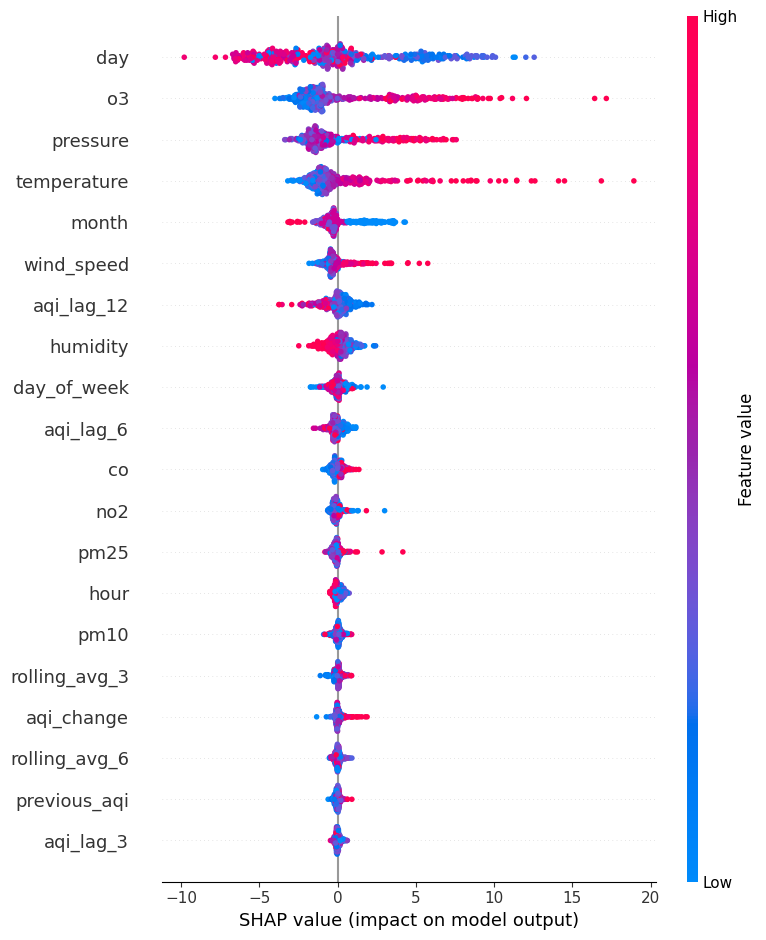

In [11]:
shap.summary_plot(
    shap_values,
    X_test
)